# TITLE AND EXPLANATION

### Libraries

In [50]:
# Visual Graphics
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib as mpl
# Web Scraping
import requests
from bs4 import BeautifulSoup
import yfinance as yf

# Data Manipulation and Computing
from datetime import timedelta
from datetime import datetime as dt
import numpy as np
import pandas as pd
from numpy import exp, sqrt, sin, cos, log, pi

# stats
import statsmodels.api as sm

#mpl.rcParams['figure.figsize'] = [10, 10]

## Importing and Data Cleaning

In [36]:
tickers = [
    'PETR4.SA',
   'ABEV3.SA',
   'MGLU3.SA',
   'AMER3.SA',
   'ITUB4.SA',
   'VALE3.SA',
   'BRFS3.SA',
   'JBSS3.SA',
   'WEGE3.SA',
   'LREN3.SA',
   'ELET3.SA',
   'GOAU4.SA',
   'GGBR4.SA',
   'BBAS3.SA',
   'PRIO3.SA',
   'RENT3.SA',
   'BHIA3.SA',
   'RAIZ4.SA',
    '^BVSP'
]

#'CIEL3.SA'

final_date = dt.today().date()
initial_date = final_date - timedelta(days=504)

prices_ = yf.download(tickers=tickers,start = initial_date, end= final_date)["Adj Close"]
#ibov = yf.download(tickers='^BVSP',start = initial_date, end= final_date)["Adj Close"] 
prices_ = prices_.interpolate(method='polynomial',order=5)

[*********************100%%**********************]  19 of 19 completed


## Projeto 1

In [3]:
prices = prices_.drop(columns=["^BVSP"])

returns = prices.pct_change(fill_method=None,axis=0) # daily returns
cum_returns = (1 + returns).cumprod(axis=0) - 1 # accumulated returns
std_dev = returns.std() # historical volatility a.a

retornos_medios = returns.mean()

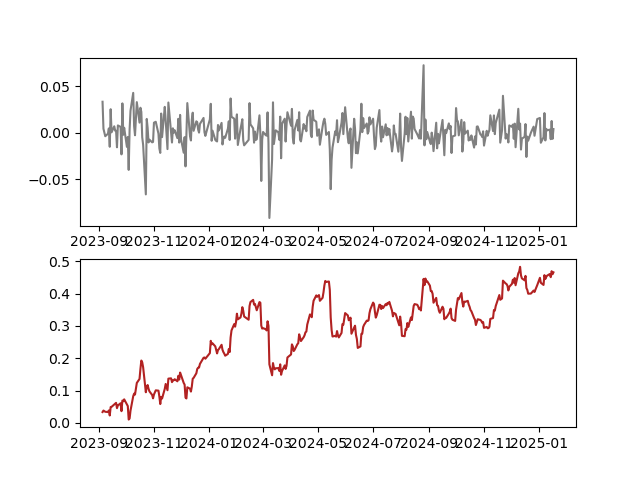

Retorno Médio Petrobras a.a: 0.315424 


In [4]:
%matplotlib widget

fig, (ax1,ax2) = plt.subplots(2,1)

ax1.plot(returns.index,
        returns['PETR4.SA'].to_numpy(),
         label = "Petrobras Diário",
         color = 'grey'
            )


ax2.plot(cum_returns.index,
        cum_returns['PETR4.SA'].to_numpy(),
         label = "Petrobras Acumulado",
         color = 'firebrick'
            )

#plt.legend() 
plt.show()

print("Retorno Médio Petrobras a.a: %f " % (retornos_medios['PETR4.SA'] * 252))

## Projeto 2

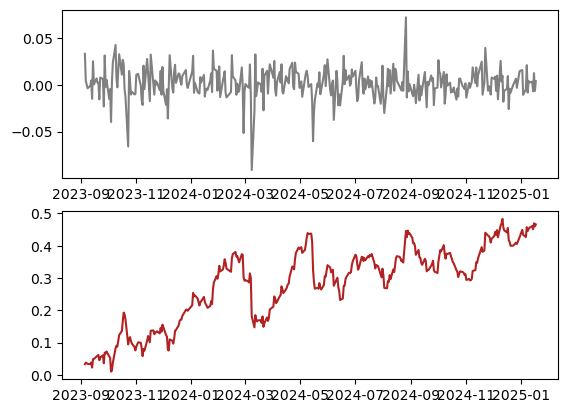

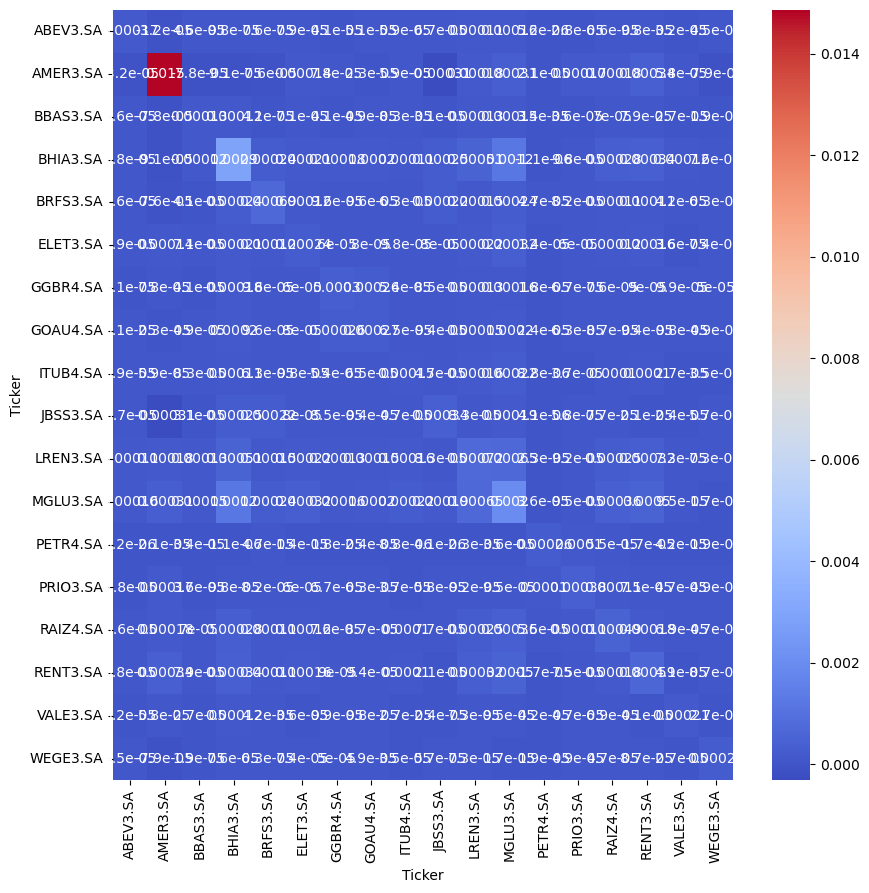

In [5]:
# matriz de covarianca

%matplotlib inline

cov = returns.cov()
cov.style.background_gradient(cmap='coolwarm')

plt.figure(figsize=(10, 10))
sns.heatmap(cov,cmap='coolwarm',annot=True,label="Correlação")

plt.show()

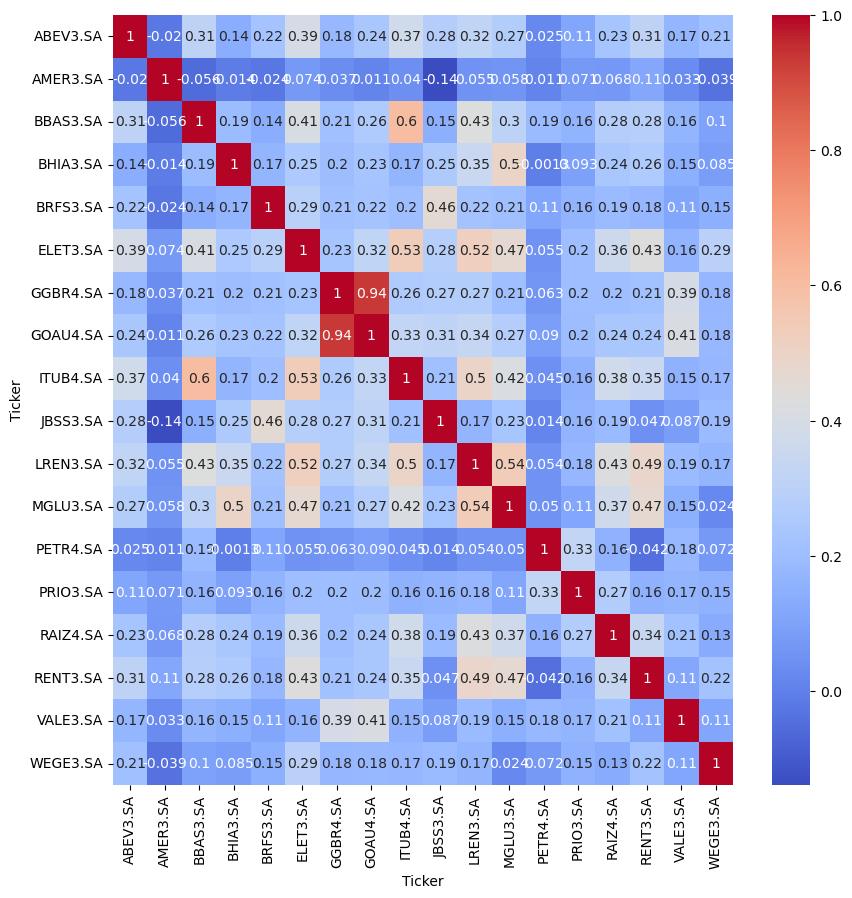

In [6]:
%matplotlib inline

# matriz de correlação

corr = returns.corr()
corr.style.background_gradient(cmap='coolwarm')

plt.figure(figsize=(10, 10))
sns.heatmap(corr,cmap='coolwarm',annot=True,label="Correlação")

plt.show()

In [7]:
def info_plotting(stock_name):
    # Volatility, Beta and Drawdown Calculations
    daily_vol = std_dev[stock_name] * 100
    monthly_vol = daily_vol * sqrt(21)
    annual_vol = daily_vol * sqrt(252)
    beta = betas[stock_name]
    
    dates = mdd_calc(stock_name)[0:2]
    values = mdd_calc(stock_name)[2:]
    print(values)
    plt.style.use('dark_background')
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

    # Daily Returns Plot
    ax1.plot(returns[stock_name] * 100, label="Retornos Diários")
    ax1.grid(linewidth=0.2)
    ax1.set_xlabel('Dates')
    ax1.set_ylabel('%')
    ax1.legend()

    # Cumulative Return & Moving Average Plot
    ax2.plot(cum_returns[stock_name] * 100, label='Retornos Acumulados a.d')
    ax2.plot(MA_cum_returns[stock_name] * 100, label="Moving Average of 21 Days")
    ax2.scatter(dates,values,label = "Drawdown Line")
    ax2.grid(linewidth=0.2)
    ax2.set_xlabel('Dates')
    ax2.set_ylabel('%')
    ax2.legend()

    # Underwater Plot
    ax3.plot(drawdown[stock_name] * 100, label="Drawdown")
    ax3.grid(linewidth=0.2)
    ax3.set_xlabel('Dates')
    ax3.set_ylabel('%')
    ax3.legend()
    ax3.fill_between(x=drawdown.index, y1=drawdown[stock_name].values * 100, y2=[0] * len(drawdown), alpha=0.35)

    fig.suptitle(stock_name)
    plt.tight_layout()
    plt.show()

    # Metrics Output
    print("Metrics on %s:" % stock_name)
    print("Daily Volatility: %f" % daily_vol)
    print("Monthly Volatility: %f" % monthly_vol)
    print("Yearly Volatility: %f" % annual_vol)
    print("MDD: %f" % (MDD * 100)[stock_name])
    print("Beta: %f" % beta)


## Projeto 3

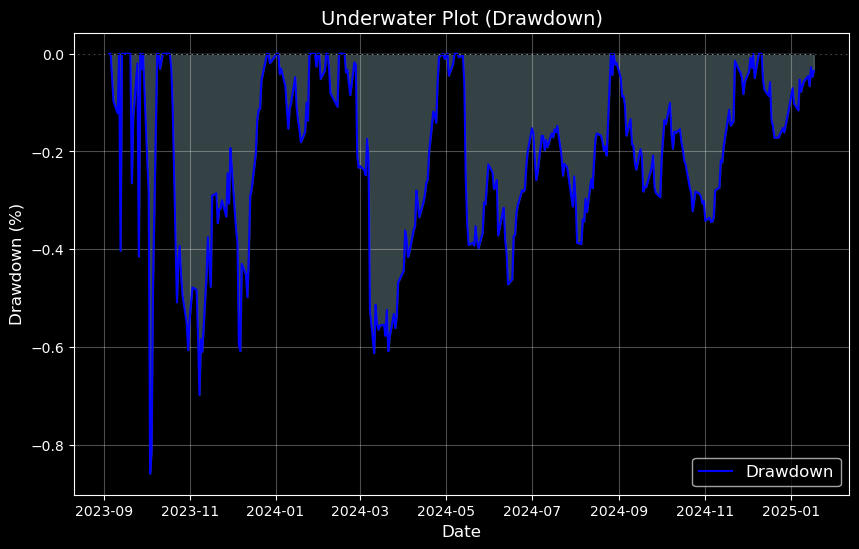

O Maximum Drawdown foi: -0.859575


In [8]:
rolling_max = cum_returns['PETR4.SA'].cummax()
drawdown = (cum_returns['PETR4.SA'] - rolling_max) / rolling_max

plt.style.use('dark_background')

plt.figure(figsize=(10, 6))
plt.plot(drawdown.index, drawdown, label="Drawdown", color="blue")
plt.fill_between(drawdown.index, drawdown, 0, color="lightblue", alpha=0.3)
plt.title("Underwater Plot (Drawdown)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Drawdown (%)", fontsize=12)
plt.axhline(0, color="black", linewidth=0.7, linestyle="--")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print("O Maximum Drawdown foi: %f" % drawdown.min())

## Projeto 4

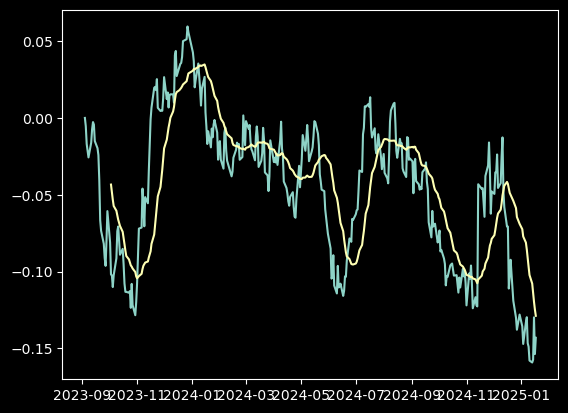

In [9]:
numero_ativos = len(returns.columns)
peso = 1 / numero_ativos

retorno_da_carteira = (returns * peso).sum(axis='columns')
acumulado_carteira = (1 + retorno_da_carteira).cumprod(axis=0) - 1
rolling_returns = acumulado_carteira.rolling(window=21).mean()

fig,ax = plt.subplots()

ax.plot(acumulado_carteira.index,acumulado_carteira)
ax.plot(rolling_returns.index,rolling_returns,label='21 Mean')
plt.show()

ax.set_xlabel("Data")
ax.set_ylabel("Retorno Acumulado")
plt.show()

## Projeto 5

In [10]:
preco_ibov = prices_['^BVSP']
retorno_bovespa = preco_ibov.pct_change(fill_method=None,axis=0).fillna(0)

mod = sm.OLS(retorno_da_carteira, retorno_bovespa)
res = mod.fit()
beta = res.params.iloc[0]
r2  = res.rsquared
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.612
Model:                            OLS   Adj. R-squared (uncentered):              0.611
Method:                 Least Squares   F-statistic:                              538.1
Date:                Sat, 18 Jan 2025   Prob (F-statistic):                    4.16e-72
Time:                        20:22:20   Log-Likelihood:                          1154.2
No. Observations:                 342   AIC:                                     -2306.
Df Residuals:                     341   BIC:                                     -2302.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
^BVSP          1.2095      0.052     23.196      0.000       1.107       1.312
==============================================================================
Omnibus:                      340.390   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25511.871
Skew:                           3.858   Prob(JB):                         0.00
Kurtosis:                      44.602   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

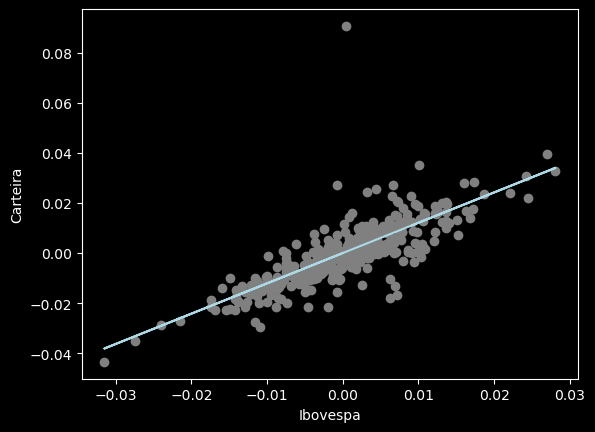

O beta foi de: 1.209498
O R^2 foi de: 0.612092


In [11]:
x =  retorno_bovespa.to_numpy()
y = retorno_da_carteira.to_numpy()

fig,ax = plt.subplots()
ax.scatter(x,y,color='grey')
ax.plot(x, beta*x,color='lightblue')
ax.set_xlabel("Ibovespa")
ax.set_ylabel("Carteira")

plt.show()

print("O beta foi de: %f" % beta )
print("O R^2 foi de: %f" % r2)

## Projeto 6

In [54]:

# 1. URL alvo
url = "https://www.infomoney.com.br/cotacoes/ibovespa/"  # Altere para a página desejada

# 2. Fazer a requisição HTTP
response = requests.get(url)
if response.status_code == 200:
    print("Página acessada com sucesso!")
else:
    print(f"Erro ao acessar a página: {response.status_code}")
    exit()

# 3. Parsing do HTML
soup = BeautifulSoup(response.content, 'html.parser')

# 4. Identificar as informações desejadas
# Inspecione o HTML para ajustar as classes ou IDs
ativos = soup.find_all("div", class_="ticker__name")  # Nome dos ativos
valores = soup.find_all("div", class_="ticker__value")  # Máxima e mínima

# 5. Organizar os dados
data = []
for ativo, valor in zip(ativos, valores):
    ativo_nome = ativo.get_text(strip=True)
    max_min = valor.get_text(strip=True).split(" | ")  # Supondo que máxima/mínima estão separadas por '|'
    maxima = max_min[0].replace("Máx: ", "")
    minima = max_min[1].replace("Min: ", "")
    data.append({"Ativo": ativo_nome, "Máxima": maxima, "Mínima": minima})

# Criar um DataFrame
df = pd.DataFrame(data)

# 6. Exibir e salvar os dados
print(df)
df.to_csv("dados_infomoney.csv", index=False)


Página acessada com sucesso!
Empty DataFrame
Columns: []
Index: []


In [53]:
maximo

[<div class="maximo">
 <p>122.674</p>
 <label>Máx (Dia)</label>
 </div>]

## Projeto 7

In [12]:
from scipy.optimize import minimize

mean_returns = returns.mean()

def portfolio_performance(weights, mean_returns, cov):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return portfolio_return, portfolio_risk

def minimize_risk(weights, mean_returns, cov):
    return portfolio_performance(weights, mean_returns, cov)[1]


In [13]:
retornos_medios

Ticker
ABEV3.SA   -0.000262
AMER3.SA   -0.003069
BBAS3.SA    0.000546
BHIA3.SA   -0.005487
BRFS3.SA    0.003027
ELET3.SA    0.000191
GGBR4.SA   -0.000344
GOAU4.SA   -0.000159
ITUB4.SA    0.000826
JBSS3.SA    0.002169
LREN3.SA    0.000010
MGLU3.SA   -0.003302
PETR4.SA    0.001252
PRIO3.SA   -0.000065
RAIZ4.SA   -0.001281
RENT3.SA   -0.001689
VALE3.SA   -0.000315
WEGE3.SA    0.001385
dtype: float64

In [15]:

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})  # Soma dos pesos = 1
bounds = tuple((0, 1) for _ in range(len(tickers)-1))  # Pesos entre 0% e 100%

initial_weights = np.array([1 / (len(tickers) - 1)] * (len(tickers) -1))
min_var_result = minimize(minimize_risk, initial_weights, args=(mean_returns, cov),
                          method='SLSQP', bounds=bounds, constraints=constraints)

min_var_weights = min_var_result.x
min_var_return, min_var_risk = portfolio_performance(min_var_weights, mean_returns, cov)


In [26]:
def efficient_frontier(mean_returns, cov_matrix, num_portfolios=100000):
    results = {'Returns': [], 'Risk': [], 'Weights': []}
    for _ in range(num_portfolios):
        weights = np.random.dirichlet(np.ones(len(tickers)-1))
        ret, risk = portfolio_performance(weights, mean_returns, cov_matrix)
        results['Returns'].append(ret)
        results['Risk'].append(risk)
        results['Weights'].append(weights)
    return pd.DataFrame(results)

portfolios = efficient_frontier(mean_returns, cov)

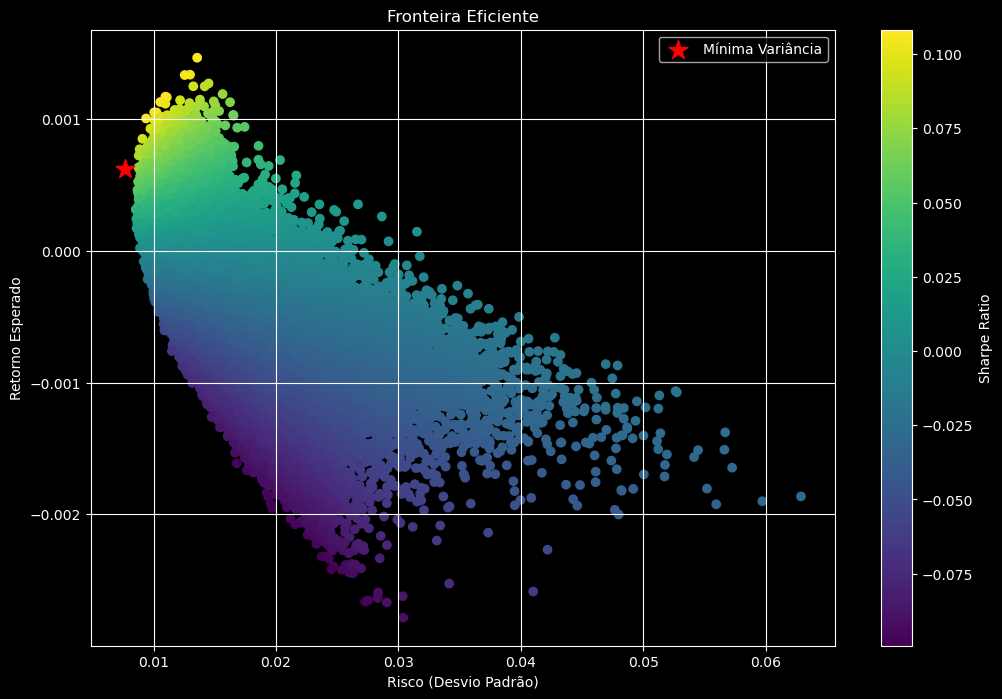

In [27]:
plt.figure(figsize=(12, 8))
plt.scatter(portfolios['Risk'], portfolios['Returns'], c=portfolios['Returns'] / portfolios['Risk'], cmap='viridis', marker='o')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(min_var_risk, min_var_return, color='red', marker='*', s=200, label='Mínima Variância')
plt.title('Fronteira Eficiente')
plt.xlabel('Risco (Desvio Padrão)')
plt.ylabel('Retorno Esperado')
plt.legend()
plt.grid()
plt.show()

In [48]:
df = pd.DataFrame(np.round(min_var_weights*100,2),index = tickers,columns=['peso ideal (%)']) 
#tickers.remove('^BVSP')
#tickers
df

,peso ideal (%)
PETR4.SA,15.24
ABEV3.SA,0.59
MGLU3.SA,18.30
AMER3.SA,0.00
ITUB4.SA,0.00
VALE3.SA,0.00
BRFS3.SA,1.52
JBSS3.SA,0.12
WEGE3.SA,13.19
LREN3.SA,6.85


In [1]:
!export PATH=/Library/TeX/texbin:$PATH

'export' não é reconhecido como um comando interno
ou externo, um programa operável ou um arquivo em lotes.
